
# White Blood Cell Segmentation — K-Means vs Fuzzy C-Means

This notebook performs segmentation of WBC nucleus using:

- **K-Means (hard clustering)**
- **Fuzzy C-Means (soft clustering)**

It also evaluates:

- Dice Score  
- IoU  
- Boundary Accuracy


In [102]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import morphology
from tqdm import tqdm


In [103]:


BASE_PATH = "/kaggle/input/raabindata-nucleus-cytoplasm-ground-truths/GrTh"

IMG_DIR = os.path.join(BASE_PATH, "Original")
GT_DIR  = os.path.join(BASE_PATH, "Ground Truth")

CLUSTERS = 3
FUZZINESS = 2.0
MAX_ITER = 100
EPS = 1e-6

In [104]:



def read_gray(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def dice_metric(pred, gt):
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    inter = np.logical_and(pred, gt).sum()
    return (2.0 * inter) / (pred.sum() + gt.sum() + EPS)


def iou_metric(pred, gt):
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + EPS)




def boundary_score(pred, gt):
    kernel = np.ones((3,3), np.uint8)

   
    pred_u8 = (pred.astype(np.uint8)) * 255
    gt_u8   = (gt.astype(np.uint8)) * 255

    p_edge = pred_u8 - cv2.erode(pred_u8, kernel)
    g_edge = gt_u8   - cv2.erode(gt_u8, kernel)

    return dice_metric(p_edge > 0, g_edge > 0)


In [105]:



def segment_kmeans(gray_img, k=3):
    h, w = gray_img.shape

    pixels = gray_img.reshape(-1, 1).astype(np.float32)

    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(pixels)

    clustered = labels.reshape(h, w)

    # choose darkest cluster as nucleus
    means = [gray_img[clustered == i].mean() for i in range(k)]
    nucleus_cluster = np.argmin(means)

    mask = (clustered == nucleus_cluster).astype(np.uint8)
    mask = morphology.remove_small_objects(mask.astype(bool), 50)

    return mask.astype(np.uint8)


In [106]:


def fuzzy_cmeans(gray_img, c=3, m=2.0, max_iter=100):
    h, w = gray_img.shape
    X = gray_img.reshape(-1, 1).astype(np.float32)
    N = X.shape[0]

    
    U = np.random.dirichlet(np.ones(c), size=N)

    for _ in range(max_iter):
        U_m = U ** m

        centers = (U_m.T @ X) / (U_m.sum(axis=0)[:, None] + EPS)

        dist = np.zeros((N, c))
        for i in range(c):
            dist[:, i] = np.linalg.norm(X - centers[i], axis=1) + EPS

        # update membership
        for i in range(c):
            denom = (dist[:, i][:, None] / dist) ** (2/(m-1))
            U[:, i] = 1.0 / denom.sum(axis=1)

    labels = np.argmax(U, axis=1).reshape(h, w)


    means = [gray_img[labels == i].mean() for i in range(c)]
    nucleus_cluster = np.argmin(means)

    mask = (labels == nucleus_cluster).astype(np.uint8)
    mask = morphology.remove_small_objects(mask.astype(bool), 50)

    return mask.astype(np.uint8)


In [107]:


def evaluate_dataset(num_samples_per_class=5, show_example=True):

    cell_types = ["Basophil", "Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]

    kmeans_dice, kmeans_iou, kmeans_boundary = [], [], []
    fcm_dice, fcm_iou, fcm_boundary = [], [], []

    shown = False  

    for cell in tqdm(cell_types, desc="Cell Types"):

        img_folder = os.path.join(IMG_DIR, cell)
        mask_folder = os.path.join(GT_DIR, cell)

        if not os.path.exists(img_folder):
            print(f"⚠️ Missing folder: {img_folder}")
            continue

        image_files = sorted([
            f for f in os.listdir(img_folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])[:num_samples_per_class]

        for file in image_files:

            img_path = os.path.join(img_folder, file)
            mask_path = os.path.join(mask_folder, file)

            if not os.path.exists(mask_path):
                continue

            gray = read_gray(img_path)
            gt_img = read_gray(mask_path)

            if gray is None or gt_img is None:
                continue

            gt_mask = gt_img > 0

    
            k_mask = segment_kmeans(gray, CLUSTERS)


            f_mask = fuzzy_cmeans(gray, CLUSTERS, FUZZINESS, MAX_ITER)

         
            kmeans_dice.append(dice_metric(k_mask, gt_mask))
            kmeans_iou.append(iou_metric(k_mask, gt_mask))
            kmeans_boundary.append(boundary_score(k_mask, gt_mask))

            fcm_dice.append(dice_metric(f_mask, gt_mask))
            fcm_iou.append(iou_metric(f_mask, gt_mask))
            fcm_boundary.append(boundary_score(f_mask, gt_mask))

  
            if show_example and not shown:
                plt.figure(figsize=(12,6))

                plt.subplot(1,4,1)
                plt.imshow(gray, cmap='gray')
                plt.title(f"Original ({cell})")
                plt.axis('off')

                plt.subplot(1,4,2)
                plt.imshow(gt_mask, cmap='gray')
                plt.title("Ground Truth")
                plt.axis('off')

                plt.subplot(1,4,3)
                plt.imshow(k_mask, cmap='gray')
                plt.title("K-Means")
                plt.axis('off')

                plt.subplot(1,4,4)
                plt.imshow(f_mask, cmap='gray')
                plt.title("Fuzzy C-Means")
                plt.axis('off')

                plt.tight_layout()
                plt.show()

                shown = True


    print("\n===== FINAL RESULTS =====")
    print("K-Means Dice:", np.mean(kmeans_dice))
    print("FCM Dice:", np.mean(fcm_dice))
    print("K-Means IoU:", np.mean(kmeans_iou))
    print("FCM IoU:", np.mean(fcm_iou))
    print("K-Means Boundary:", np.mean(kmeans_boundary))
    print("FCM Boundary:", np.mean(fcm_boundary))

Cell Types:   0%|          | 0/5 [00:00<?, ?it/s]

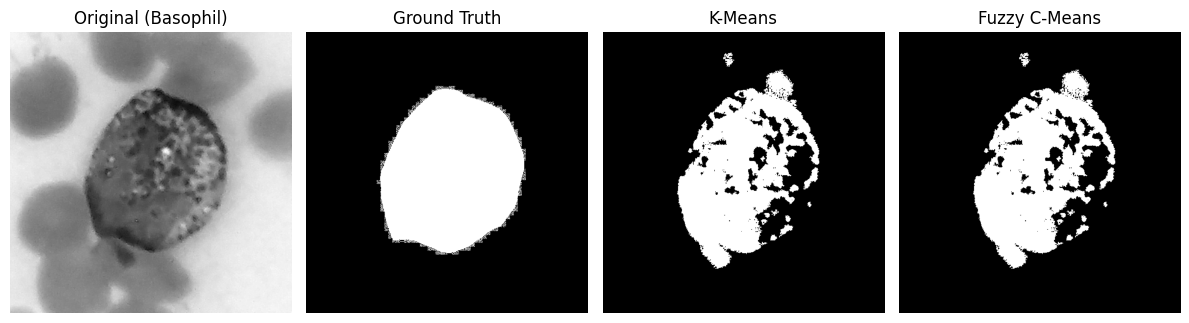

Cell Types: 100%|██████████| 5/5 [02:35<00:00, 31.17s/it]


===== FINAL RESULTS =====
K-Means Dice: 0.4811906019711188
FCM Dice: 0.46081720583205454
K-Means IoU: 0.35500023020807825
FCM IoU: 0.33308902493310777
K-Means Boundary: 0.017916649602456532
FCM Boundary: 0.017571550867817694


In [108]:

evaluate_dataset()

K-Means provided fast and reasonably accurate nucleus segmentation but struggled near fuzzy boundaries.
Fuzzy C-Means produced smoother and more precise segmentation results due to soft clustering.
Overall, FCM is more suitable for WBC nucleus segmentation when accuracy is prioritized over speed.